# Validação do modelo de risco - AgroKraken Sprint 2

**Responsável:** Vinicius Anjos (RM572814)  
**Parte:** ML + validação  

Este notebook reproduz a leitura dos artefatos do modelo, mostra as principais métricas da validação e gera figuras em matplotlib para apoiar a apresentação da Sprint 2 Sompo.


In [1]:
from pathlib import Path
import sys
import json

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, precision_score, recall_score
from sklearn.model_selection import train_test_split


def find_task_root():
    current = Path.cwd().resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "data" / "dataset_simulado.csv").exists() and (candidate / "ml").exists():
            return candidate
    raise FileNotFoundError("Rode o notebook dentro de tasks/task09_sompo_sprint2")


BASE_DIR = find_task_root()
if str(BASE_DIR) not in sys.path:
    sys.path.insert(0, str(BASE_DIR))

DATA_PATH = BASE_DIR / "data" / "dataset_simulado.csv"
MODEL_PATH = BASE_DIR / "models" / "risk_model.joblib"
METRICS_PATH = BASE_DIR / "models" / "risk_model_metrics.json"
IMPORTANCE_PATH = BASE_DIR / "models" / "feature_importance.csv"

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "#fbfcfe",
    "axes.edgecolor": "#d7dee8",
    "axes.labelcolor": "#243447",
    "axes.titleweight": "bold",
    "axes.titlesize": 14,
    "axes.labelsize": 10.5,
    "xtick.color": "#536170",
    "ytick.color": "#536170",
    "grid.color": "#e8edf3",
    "grid.linestyle": "-",
    "grid.linewidth": 0.8,
    "font.size": 10.5,
})

print(f"Task root: {BASE_DIR}")
print(f"Modelo: {MODEL_PATH.relative_to(BASE_DIR)}")

Task root: C:\Users\Vinicius\Documents\fiap\tasks\task09_sompo_sprint2
Modelo: models\risk_model.joblib


In [2]:
df = pd.read_csv(DATA_PATH)
bundle = joblib.load(MODEL_PATH)
metrics = json.loads(METRICS_PATH.read_text(encoding="utf-8"))
importance = pd.read_csv(IMPORTANCE_PATH)

features = bundle["feature_columns"]
target = bundle["target_column"]
threshold = float(bundle["threshold"])
pipeline = bundle["pipeline"]

x = df[features].copy()
y = df[target].astype(int)
_, x_test, _, y_test = train_test_split(
    x,
    y,
    test_size=metrics["dataset"]["test_size"],
    stratify=y,
    random_state=metrics["dataset"]["random_state"],
)

positive_index = list(pipeline.classes_).index(1)
prob_test = pipeline.predict_proba(x_test)[:, positive_index]
score_test = np.rint(prob_test * 100).astype(int)
pred_test = (prob_test >= threshold).astype(int)
cm = confusion_matrix(y_test, pred_test, labels=[0, 1])

summary = metrics["classification_metrics"]
print(f"Linhas totais: {len(df)}")
print(f"Teste holdout: {len(x_test)} registros")
print(f"Threshold de alerta: {threshold:.2f} (score >= {round(threshold * 100)})")
print(f"Recall: {summary['recall']:.4f} | Precision: {summary['precision']:.4f} | F1: {summary['f1_score']:.4f} | ROC AUC: {summary['roc_auc']:.4f}")

Linhas totais: 600
Teste holdout: 150 registros
Threshold de alerta: 0.34 (score >= 34)
Recall: 0.9630 | Precision: 0.9512 | F1: 0.9571 | ROC AUC: 0.9846


## 1. Distribuição do target

A base simulada tem uma proporção levemente maior de operações com `risco_label=1`, o que ajuda o modelo a aprender padrões de alerta sem ficar dominado por uma classe majoritária.


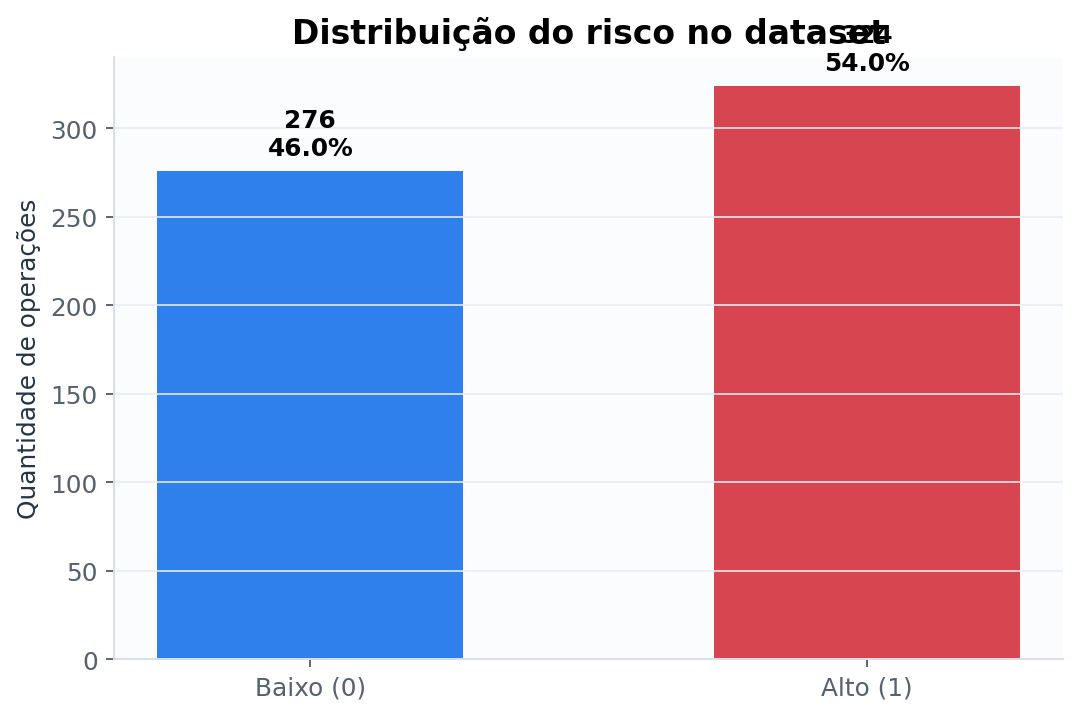

In [3]:
counts = df[target].value_counts().sort_index()
labels = ["Baixo (0)", "Alto (1)"]
colors = ["#2f80ed", "#d64550"]

fig, ax = plt.subplots(figsize=(7.2, 4.6))
bars = ax.bar(labels, counts.values, color=colors, width=0.55)
ax.set_title("Distribuição do risco no dataset")
ax.set_ylabel("Quantidade de operações")
ax.grid(axis="y", alpha=0.85)
ax.spines[["top", "right"]].set_visible(False)

for bar, value in zip(bars, counts.values):
    pct = value / len(df) * 100
    ax.text(bar.get_x() + bar.get_width() / 2, value + 6, f"{value}\n{pct:.1f}%", ha="center", va="bottom", fontweight="bold")

plt.show()

## 2. Matriz de confusão

A matriz abaixo usa o conjunto holdout de 150 registros. Como o problema é preventivo, o principal ponto de atenção é o quadrante de falsos negativos: operações de alto risco que não viram alerta.


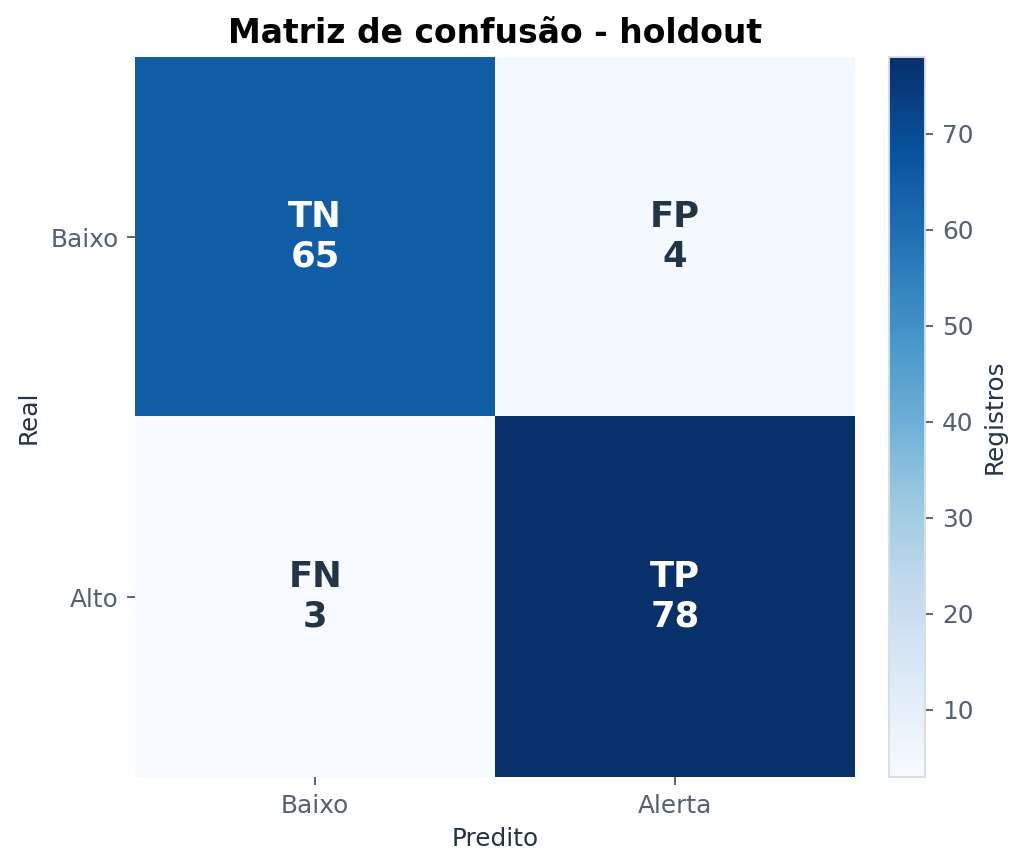

In [4]:
fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(cm, cmap="Blues")
ax.set_title("Matriz de confusão - holdout")
ax.set_xlabel("Predito")
ax.set_ylabel("Real")
ax.set_xticks([0, 1], ["Baixo", "Alerta"])
ax.set_yticks([0, 1], ["Baixo", "Alto"])

labels_matrix = [["TN", "FP"], ["FN", "TP"]]
for i in range(2):
    for j in range(2):
        value = cm[i, j]
        color = "white" if value > cm.max() * 0.55 else "#243447"
        ax.text(j, i, f"{labels_matrix[i][j]}\n{value}", ha="center", va="center", color=color, fontsize=15, fontweight="bold")

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Registros")
ax.spines[:].set_visible(False)
plt.show()

## 3. Métricas principais

A Sprint 1 definiu **recall** como métrica central. Nesta validação, o modelo alcança 96,30% de recall para `risco_label=1`.


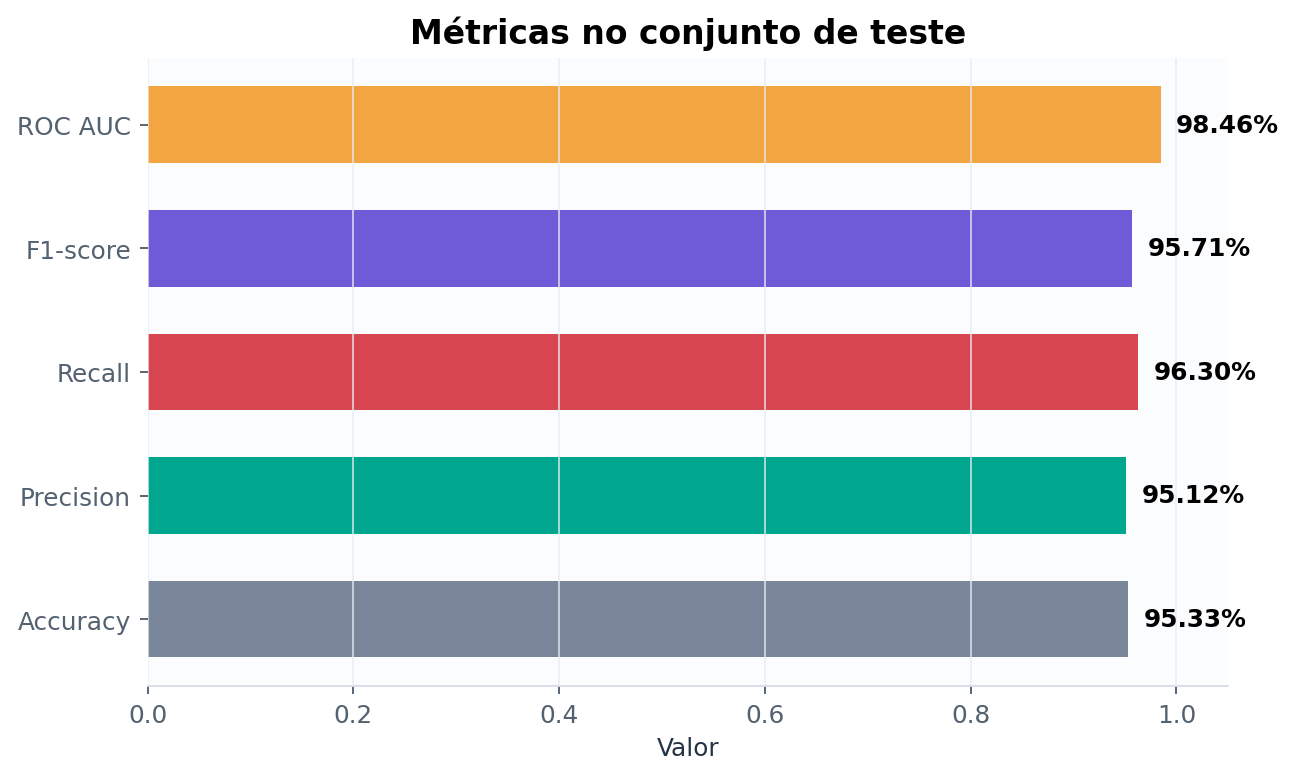

In [5]:
metric_labels = ["Accuracy", "Precision", "Recall", "F1-score", "ROC AUC"]
metric_values = [
    summary["accuracy"],
    summary["precision"],
    summary["recall"],
    summary["f1_score"],
    summary["roc_auc"],
]
colors = ["#7a869a", "#00a78e", "#d64550", "#6f5bd7", "#f2a541"]

fig, ax = plt.subplots(figsize=(8.2, 4.8))
y_pos = np.arange(len(metric_labels))
bars = ax.barh(y_pos, metric_values, color=colors, height=0.62)
ax.set_yticks(y_pos, metric_labels)
ax.set_xlim(0, 1.05)
ax.set_xlabel("Valor")
ax.set_title("Métricas no conjunto de teste")
ax.grid(axis="x", alpha=0.75)
ax.spines[["top", "right", "left"]].set_visible(False)

for bar, value in zip(bars, metric_values):
    ax.text(value + 0.015, bar.get_y() + bar.get_height() / 2, f"{value:.2%}", va="center", fontweight="bold")

plt.show()

## 4. Importância das variáveis

A ordenação é coerente com as regras de risco da base: distância de corpo d'água, tipo de solo, umidade, chuva e histórico de sinistros concentram a maior explicação do modelo.


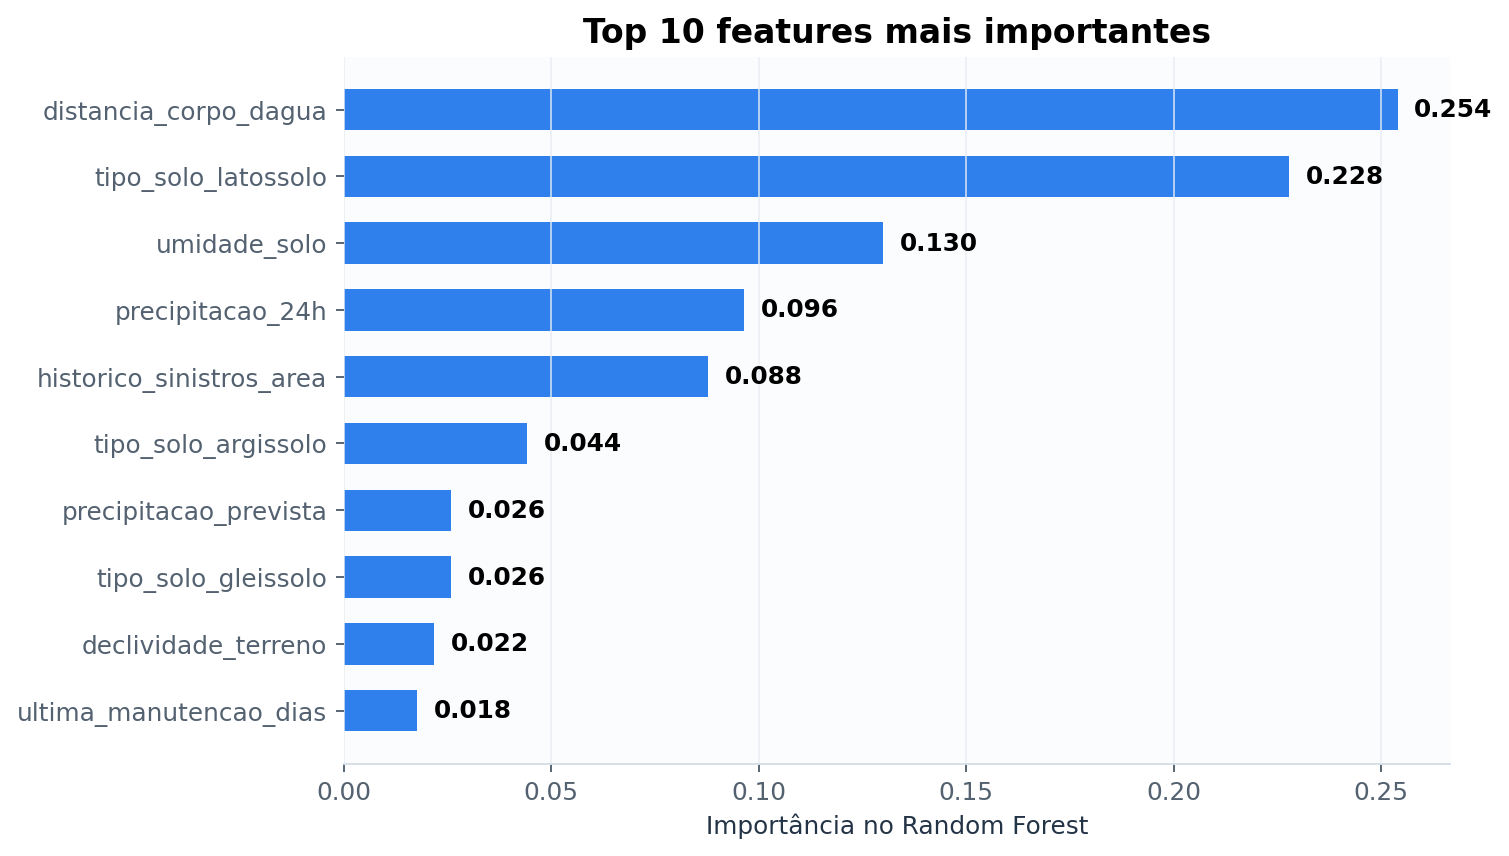

In [6]:
top_importance = importance.head(10).sort_values("importance")

fig, ax = plt.subplots(figsize=(8.4, 5.4))
bars = ax.barh(top_importance["feature"], top_importance["importance"], color="#2f80ed", height=0.62)
ax.set_title("Top 10 features mais importantes")
ax.set_xlabel("Importância no Random Forest")
ax.grid(axis="x", alpha=0.75)
ax.spines[["top", "right", "left"]].set_visible(False)

for bar, value in zip(bars, top_importance["importance"]):
    ax.text(value + 0.004, bar.get_y() + bar.get_height() / 2, f"{value:.3f}", va="center", fontweight="bold")

plt.show()

## 5. Distribuição dos scores no holdout

O score é a probabilidade de risco alto convertida para 0-100. A linha tracejada marca o início da faixa `medio`, usada como threshold de alerta acionável na validação.


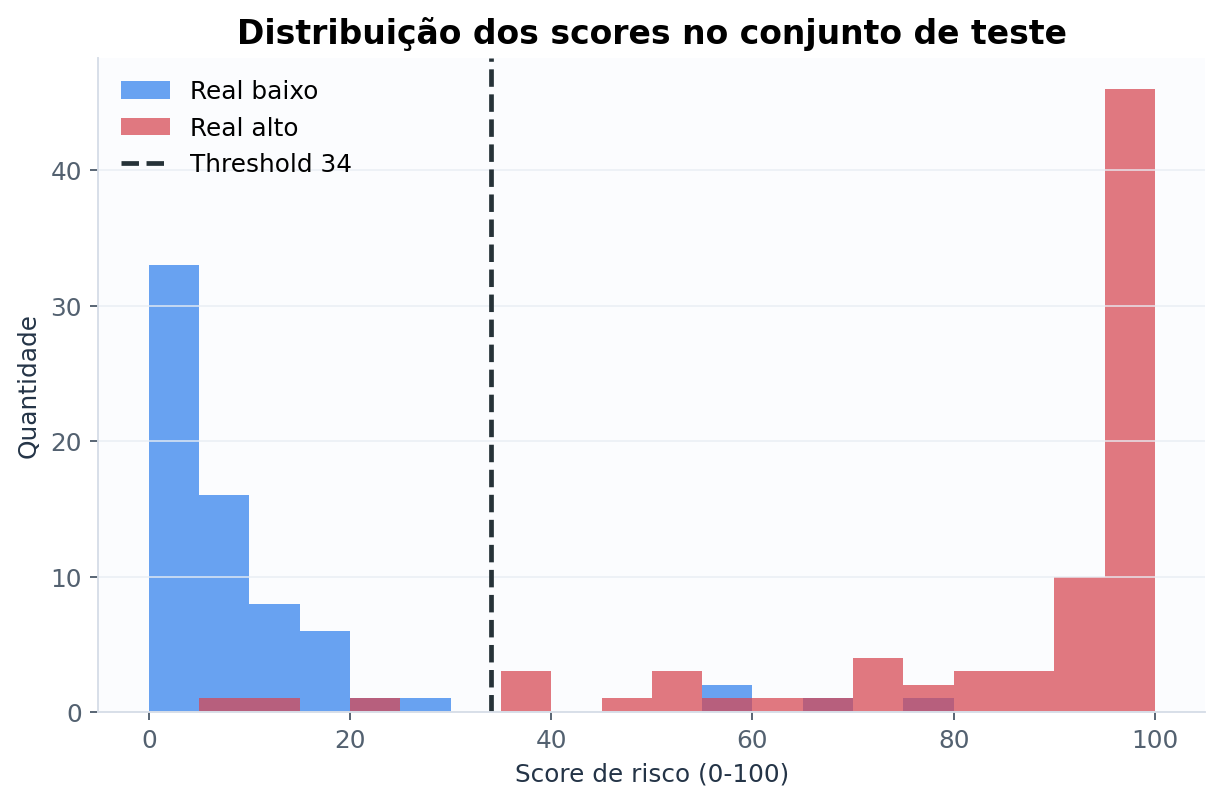

In [7]:
score_view = pd.DataFrame({"risco_real": y_test.to_numpy(), "score": score_test})
bins = np.arange(0, 105, 5)

fig, ax = plt.subplots(figsize=(8.4, 5.0))
ax.hist(score_view.loc[score_view["risco_real"] == 0, "score"], bins=bins, alpha=0.72, label="Real baixo", color="#2f80ed")
ax.hist(score_view.loc[score_view["risco_real"] == 1, "score"], bins=bins, alpha=0.72, label="Real alto", color="#d64550")
ax.axvline(round(threshold * 100), color="#263238", linestyle="--", linewidth=2, label=f"Threshold {round(threshold * 100)}")
ax.set_title("Distribuição dos scores no conjunto de teste")
ax.set_xlabel("Score de risco (0-100)")
ax.set_ylabel("Quantidade")
ax.legend(frameon=False)
ax.grid(axis="y", alpha=0.75)
ax.spines[["top", "right"]].set_visible(False)
plt.show()

## 6. Trade-off por threshold

O threshold `0.34` foi escolhido porque mantém recall alto sem derrubar precision. Para o Carlos, operador, isso significa uma solução mais preventiva.


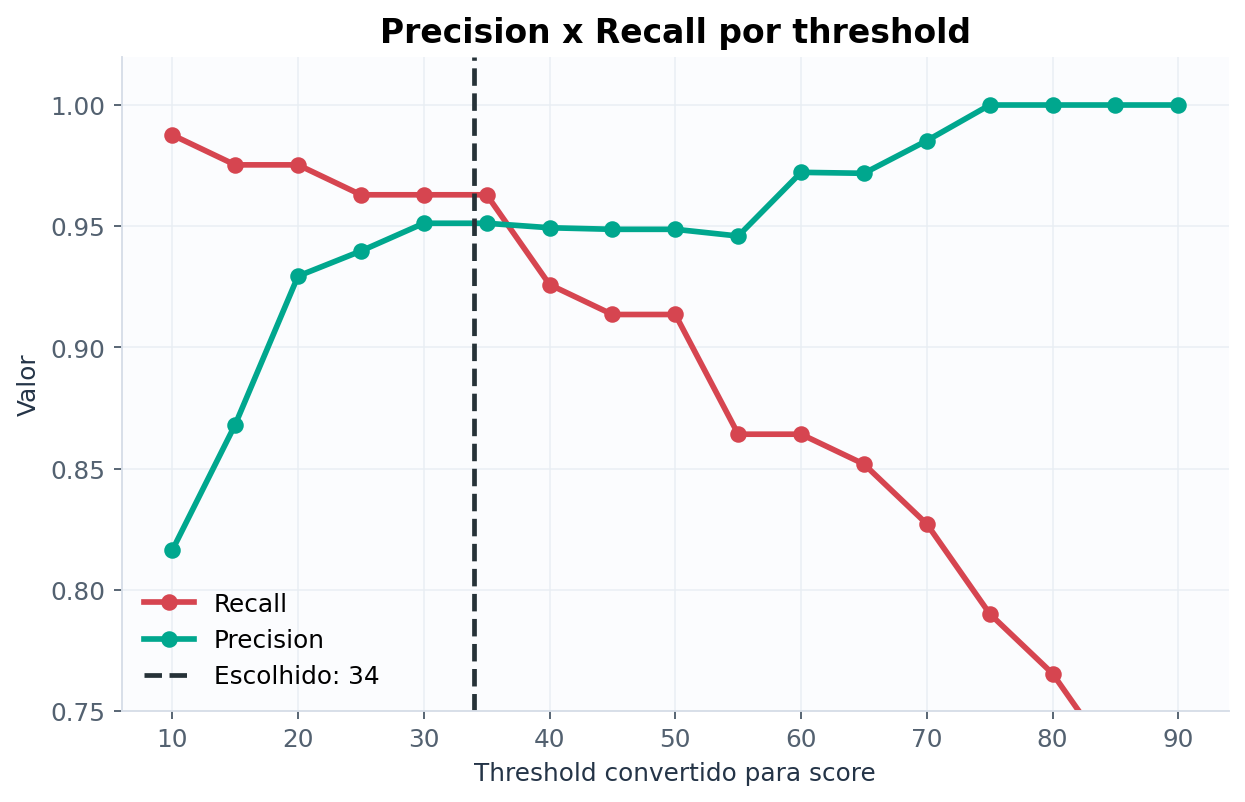

In [8]:
thresholds = np.linspace(0.10, 0.90, 17)
precision_values = []
recall_values = []

for candidate in thresholds:
    candidate_pred = (prob_test >= candidate).astype(int)
    precision_values.append(precision_score(y_test, candidate_pred, zero_division=0))
    recall_values.append(recall_score(y_test, candidate_pred, zero_division=0))

fig, ax = plt.subplots(figsize=(8.4, 5.0))
ax.plot(thresholds * 100, recall_values, marker="o", linewidth=2.4, color="#d64550", label="Recall")
ax.plot(thresholds * 100, precision_values, marker="o", linewidth=2.4, color="#00a78e", label="Precision")
ax.axvline(threshold * 100, color="#263238", linestyle="--", linewidth=2, label=f"Escolhido: {threshold * 100:.0f}")
ax.set_title("Precision x Recall por threshold")
ax.set_xlabel("Threshold convertido para score")
ax.set_ylabel("Valor")
ax.set_ylim(0.75, 1.02)
ax.legend(frameon=False, loc="lower left")
ax.grid(alpha=0.75)
ax.spines[["top", "right"]].set_visible(False)
plt.show()

## 7. Contrato de predição para o dashboard

A função `predict_risk_score(row)` recebe uma linha do CSV em formato `dict` e devolve score, categoria, tipo de risco e recomendação. Este é o ponto de integração com `dashboard/app.py`.


In [9]:
from ml.predict import predict_risk_score

examples = pd.concat([
    df[df[target] == 0].head(1),
    df[df[target] == 1].head(1),
])

rows = []
for _, row in examples.iterrows():
    result = predict_risk_score(row.to_dict())
    rows.append({
        "equipamento_id": row["equipamento_id"],
        "risco_label": int(row[target]),
        "score": result["score"],
        "categoria": result["categoria"],
        "tipo_risco": result["tipo_risco"],
        "recomendacao": result["recomendacao"],
    })

pd.DataFrame(rows)

equipamento_id,risco_label,score,categoria,tipo_risco,recomendacao
TRAT-001,0,3,baixo,operação em condições controladas,"Operação liberada, mantendo monitoramento de rotina dos sensores e clima."
TRAT-001,1,96,alto,proximidade alta de corpo d'água,Adiar a operação ou acionar a gestão antes de seguir; principal fator: proximidade alta de corpo d'água.


## Conclusão

O Random Forest atende ao contrato da Sprint 2: score 0-100, categorias operacionais, recomendação para o operador e validação com recall documentado. Os gráficos reforçam que o modelo está coerente com o problema: prevenir sinistros em áreas próximas a água, solos mais sensíveis, chuva/umidade elevada e histórico de ocorrências.
